In [300]:
#data libraries
import pandas as pd
import numpy as np

#visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

#text/NLP libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.util import ngrams
from collections import Counter

#ML work phase 1.2, vectorization and phase 2
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import chi2

#NLTK data downloads
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/bahadirkocabas/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/bahadirkocabas/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bahadirkocabas/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [301]:
df = pd.read_csv('../data/raw/medicaltranscriptionsamples.csv') #relative data path
df.head(3) #to see the first 5 rows of the dataset

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."


In [302]:
df = df.drop(columns=['Unnamed: 0']) #to drop the first column which is an index column
df.info() #to get a concise summary of the DataFrame, including the number of non

<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   description        4999 non-null   str  
 1   medical_specialty  4999 non-null   str  
 2   sample_name        4999 non-null   str  
 3   transcription      4966 non-null   str  
 4   keywords           3931 non-null   str  
dtypes: str(5)
memory usage: 195.4 KB


phase1.1 removing nulls, droping exact duplicates, and short notes under 20char

In [303]:
print(df['medical_specialty'].isna().sum()) #checking for missing values 
print(df['transcription'].isna().sum())

0
33


In [304]:
df = df.dropna(subset=['medical_specialty','transcription']) #to drop rows with missing values in the 'medical_specialty' column and transcription column
print(df.shape[0])
df['medical_specialty'] = df['medical_specialty'].str.strip() #to remove leading and trailing whitespace from the 'medical_specialty' column
df['transcription'] = df['transcription'].str.strip() #to remove leading and trailing whitespace from the 'transcription' column

df = df.drop_duplicates(subset=['transcription', 'medical_specialty']) #to drop duplicate rows based on the 'transcription' column, if they had exact same notes
print(df.shape[0])

df = df[df['transcription'].str.len() >= 20] #to filter the DataFrame to only include rows where the length of the 'transcription' column is at least 20 characters
print(df.shape[0]) #to check the shape of the DataFrame after filtering out short transcriptions


4966
4964
4951


phase 1.1 feature extraction

In [305]:
df['char_lenght'] = df['transcription'].str.len() #to create a new column 'char_length' that contains the length of the text in the 'transcription' column
df['word_count'] = df['transcription'].str.split().apply(len) #to create a new column 'word_count' that contains the number, splitting by whitespace
df['sentence_count'] = df['transcription'].apply(lambda note: len(sent_tokenize(note))) #to create a new column 'sentence_count' that contains the number of sentences in the 'transcription' column, we could use a regular function as well
df.head(3)


,description,medical_specialty,sample_name,transcription,keywords,char_lenght,word_count,sentence_count
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller...",1331,204,17
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh...",2431,350,25
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart...",4422,716,53


1.1 visuals

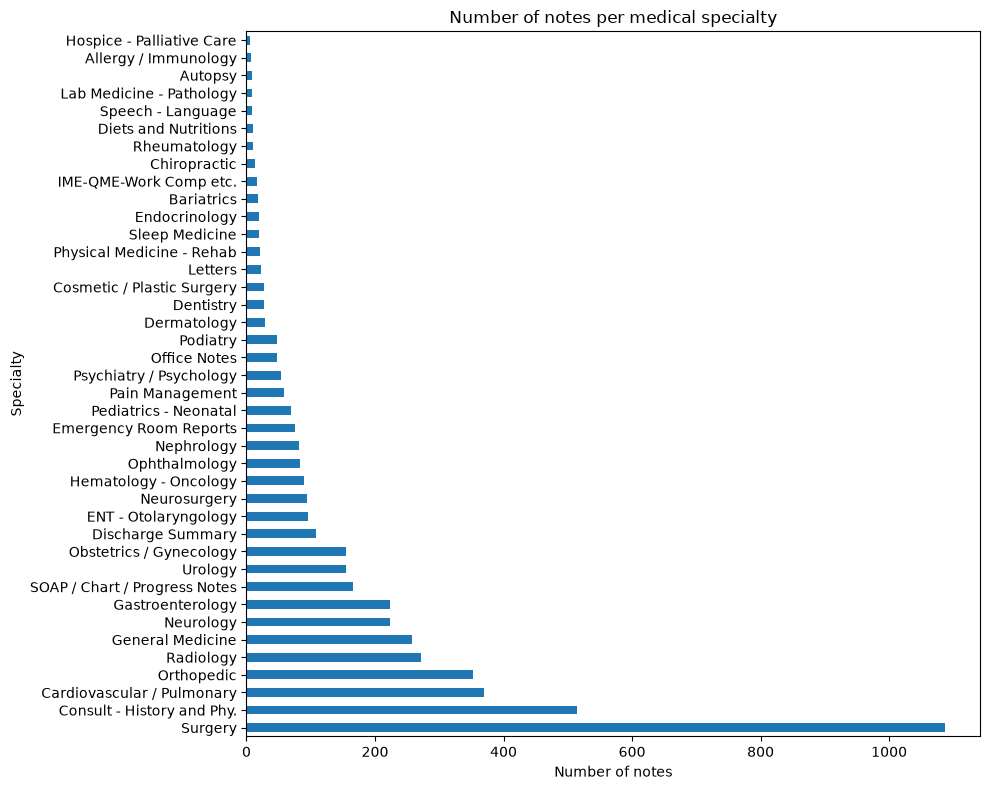

In [306]:
plt.figure(figsize=(10, 8))
df['medical_specialty'].value_counts().plot(kind='barh')
plt.title('Number of notes per medical specialty')
plt.xlabel('Number of notes')
plt.ylabel('Specialty')
plt.tight_layout()
plt.show()

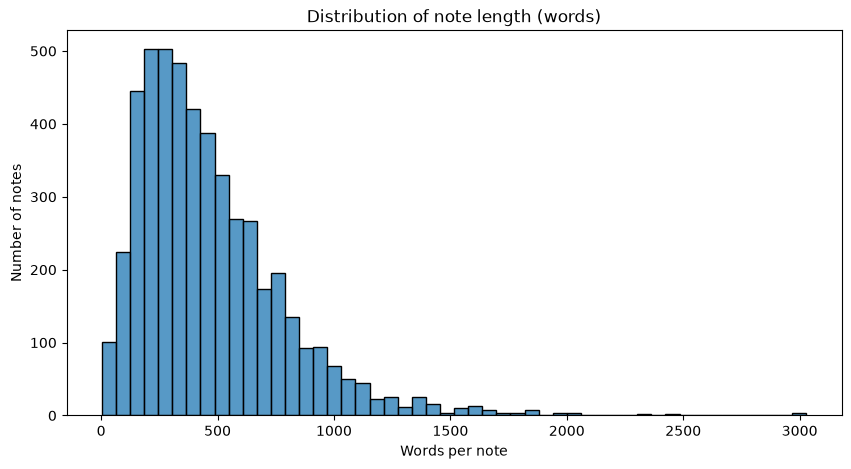

In [307]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='word_count', bins=50)
plt.title('Distribution of note length (words)')
plt.xlabel('Words per note')
plt.ylabel('Number of notes')
plt.show()

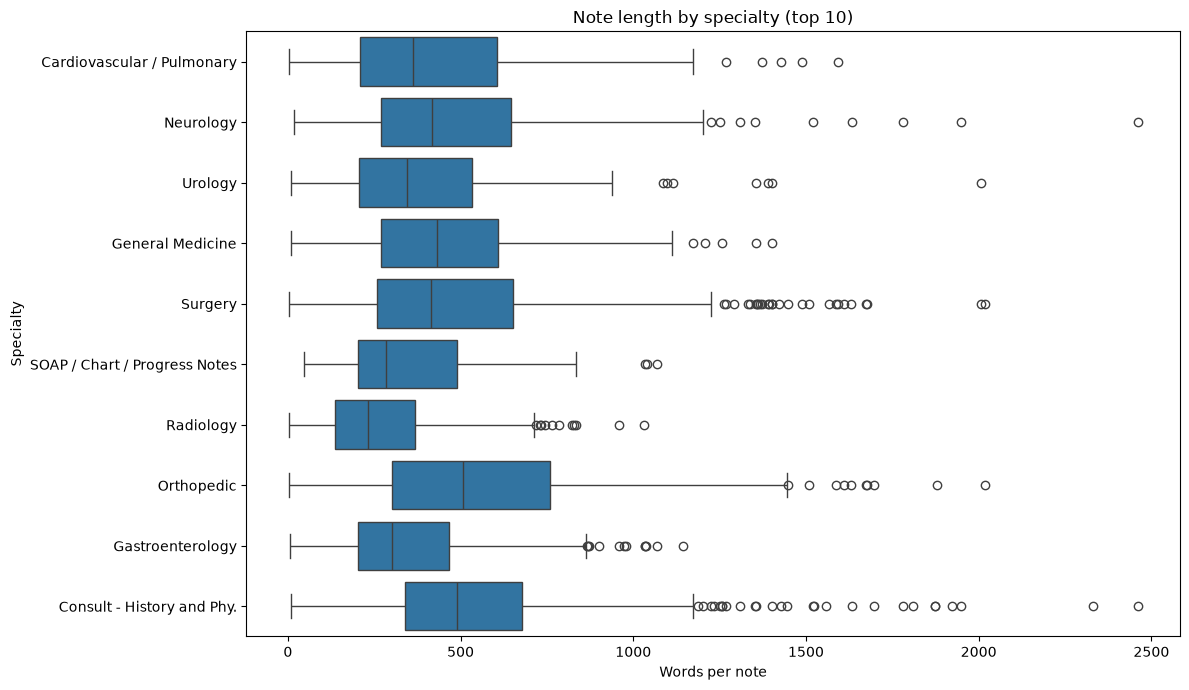

In [308]:
# keep only the 10 most common specialties so the plot stays readable
top_specialties = df['medical_specialty'].value_counts().head(10).index
subset = df[df['medical_specialty'].isin(top_specialties)]

plt.figure(figsize=(12, 7))
sns.boxplot(data=subset, x='word_count', y='medical_specialty')
plt.title('Note length by specialty (top 10)')
plt.xlabel('Words per note')
plt.ylabel('Specialty')
plt.tight_layout()
plt.show()

1.2 NLP analysis

In [322]:
#cleaning the text data for vectorization and ML work
stop = set(stopwords.words('english'))

def clean(text):
    text = text.lower()                          # 1. lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)        # 2. remove punctuation/digits
    words = text.split()                         # 3. tokenize
    words = [w for w in words if w not in stop]  # 4. drop stopwords, using a list comprehension to filter out stopwords
    return ' '.join(words)                        # 5. rejoin

df['clean_text'] = df['transcription'].apply(clean)

df.head(1)

,description,medical_specialty,sample_name,transcription,keywords,char_lenght,word_count,sentence_count,clean_text
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller...",1331,204,17,subjective year old white female presents comp...


In [323]:
all_words = ' '.join(df['clean_text']).split() #create a list of all words in the 'clean_text' column by joininn and splitting the text returning a list of words to counter work
top20 = Counter(all_words).most_common(20)
print("Top 20 most common words:", top20)

Top 20 most common words: [('patient', 24206), ('right', 11587), ('left', 11258), ('history', 9509), ('normal', 7526), ('procedure', 7462), ('placed', 7028), ('well', 6611), ('pain', 5976), ('mg', 4375), ('x', 4357), ('noted', 4348), ('also', 4337), ('time', 4287), ('c', 4132), ('using', 4123), ('blood', 3956), ('performed', 3953), ('skin', 3798), ('without', 3732)]


In [324]:
print("total rows:", len(df))
print("unique transcriptions:", df['transcription'].nunique())
dup = df['transcription'].duplicated().sum()
print("duplicate transcription rows:", dup)

total rows: 4951
unique transcriptions: 2351
duplicate transcription rows: 2600


In [325]:
for specialty in df['medical_specialty'].value_counts().head(5).index:
    notes = df[df['medical_specialty'] == specialty]['clean_text']
    words = ' '.join(notes).split()
    top = Counter(words).most_common(20)
    print(f"\n=== {specialty} ===")
    print(top) 


=== Surgery ===
[('patient', 5344), ('left', 3263), ('right', 3261), ('procedure', 3243), ('placed', 3025), ('using', 1754), ('anesthesia', 1687), ('well', 1645), ('incision', 1641), ('removed', 1574), ('used', 1487), ('performed', 1469), ('skin', 1257), ('room', 1216), ('diagnosis', 1213), ('taken', 1151), ('fashion', 1115), ('noted', 1114), ('artery', 1078), ('position', 1064)]

=== Consult - History and Phy. ===
[('patient', 3326), ('history', 2820), ('normal', 1368), ('pain', 1153), ('mg', 946), ('right', 895), ('past', 843), ('left', 803), ('also', 798), ('well', 797), ('year', 685), ('time', 675), ('medical', 638), ('denies', 634), ('negative', 628), ('old', 627), ('examination', 625), ('blood', 600), ('medications', 594), ('without', 570)]

=== Cardiovascular / Pulmonary ===
[('patient', 1662), ('left', 1550), ('right', 1300), ('artery', 1085), ('coronary', 681), ('history', 654), ('normal', 648), ('procedure', 648), ('chest', 547), ('mg', 454), ('catheter', 450), ('heart', 436

In [326]:
df.to_csv('../data/processed/cleaned_medical_notes.csv', index=False) #to save the cleaned DataFrame to a new CSV file in the 'processed' directory, without including the index column

In [327]:
words = ' '.join(df['clean_text']).split()      # same flat word list as before
bigrams = Counter(ngrams(words, 2)).most_common(20)
trigrams = Counter(ngrams(words, 3)).most_common(20)
print("Bigrams:", bigrams)
print("Trigrams:", trigrams)



Bigrams: [(('year', 'old'), 2943), (('c', 'c'), 1808), (('operating', 'room'), 1594), (('prepped', 'draped'), 1498), (('patient', 'year'), 1319), (('blood', 'pressure'), 1265), (('dr', 'x'), 1256), (('medical', 'history'), 1223), (('preoperative', 'diagnosis'), 1176), (('physical', 'examination'), 1156), (('procedure', 'patient'), 1152), (('tolerated', 'procedure'), 1124), (('vital', 'signs'), 1121), (('procedure', 'well'), 1115), (('past', 'medical'), 1113), (('incision', 'made'), 1106), (('postoperative', 'diagnosis'), 1092), (('history', 'present'), 1060), (('present', 'illness'), 1050), (('coronary', 'artery'), 1032)]
Trigrams: [(('patient', 'year', 'old'), 1303), (('past', 'medical', 'history'), 1063), (('history', 'present', 'illness'), 1042), (('tolerated', 'procedure', 'well'), 1035), (('patient', 'tolerated', 'procedure'), 923), (('prepped', 'draped', 'usual'), 801), (('estimated', 'blood', 'loss'), 754), (('c', 'c', 'c'), 735), (('year', 'old', 'female'), 661), (('taken', 'op

phase 2.1, chi square test for whole text without any speciality

In [328]:
# 1. build the document-term matrix from cleaned text
vectorizer = CountVectorizer(max_features=5000, stop_words =  ['x', 'xx', 'xxx', 'dr', 'md', 'mrs', 'dear', 'abc', 'xyz', 'mmddyyyy', 'yyyy', 'dd', 'yearold']) #to create a CountVectorizer object with a maximum of 5000 features, and remove some noise words like de identified words and common words that are not informative for specialty classification
X = vectorizer.fit_transform(df['clean_text']) #clean text notes for chi-square analysis 1part of matrix
y = df['medical_specialty'] #other part of patrix, the labels for chi-square analysis

# 2. run chi-square: score every word against the specialty labels
chi2_scores, p_values = chi2(X, y)

# 3. pair each word with its score
feature_names = vectorizer.get_feature_names_out()
scores = pd.DataFrame({'word': feature_names, 'chi2': chi2_scores})

# 4. the most "specialty-bonded" words overall
scores.sort_values('chi2', ascending=False).head(20)



,word,chi2
1630,eye,10161.603750
2872,mr,7806.366266
4112,sleep,7743.664196
4597,tooth,7719.907055
2205,inch,7606.287922
4543,thyroid,7583.937219
2085,history,7301.031890
942,contains,7299.539851
638,carbohydrate,6385.608697
744,chiropractic,6022.329335


phase2.1 chi square test for speciality based

In [329]:
# specialties to profile — use exact labels from your data
specialties = df['medical_specialty'].value_counts().index

for target in specialties:
    # binary target: is this note the target specialty, yes/no?
    y_binary = (df['medical_specialty'] == target)

    # same X, same test — only y changed
    chi2_scores, p_values = chi2(X, y_binary)

    # pair words with scores, take the top 10 for this specialty
    scores = pd.DataFrame({
        'word': vectorizer.get_feature_names_out(),
        'chi2': chi2_scores
    }).sort_values('chi2', ascending=False).head(50)

    print(f"\n=== {target} ===")
    print(scores['word'].tolist())


=== Surgery ===
['procedure', 'placed', 'history', 'anesthesia', 'incision', 'removed', 'using', 'used', 'fashion', 'vicryl', 'suture', 'closed', 'mg', 'preoperative', 'pain', 'operating', 'prepped', 'draped', 'taken', 'sterile', 'catheter', 'postoperative', 'past', 'position', 'performed', 'normal', 'denies', 'negative', 'made', 'diagnosis', 'fascia', 'dissection', 'hemostasis', 'daily', 'inserted', 'day', 'sutures', 'medications', 'applied', 'allergies', 'medical', 'mm', 'tissue', 'recovery', 'physical', 'irrigated', 'rate', 'examination', 'operative', 'room']

=== Consult - History and Phy. ===
['history', 'past', 'denies', 'allergies', 'medical', 'family', 'social', 'procedure', 'negative', 'placed', 'review', 'systems', 'medications', 'mg', 'years', 'examination', 'pain', 'daily', 'normal', 'physical', 'hypertension', 'mother', 'present', 'illness', 'currently', 'alcohol', 'heent', 'extremities', 'anesthesia', 'incision', 'weight', 'problems', 'clear', 'diabetes', 'heart', 'using

phase 2.2, n gram analysis

In [330]:
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder

bigram_measures = BigramAssocMeasures()

# tokenize all cleaned text into one word list
words = ' '.join(df['clean_text']).split()

# build the finder (tallies co-occurrences + individual frequencies)
finder = BigramCollocationFinder.from_words(words)

# only keep pairs seen at least 5 times — PMI is unstable for rare pairs
finder.apply_freq_filter(5)

# score by PMI, take the top 20
top_pmi = finder.nbest(bigram_measures.pmi, 20)
top_pmi

[('ssa', 'ssb'),
 ('zig', 'zag'),
 ('au', 'lait'),
 ('blighted', 'ovum'),
 ('cafe', 'au'),
 ('chronos', 'vertefill'),
 ('corrugator', 'procerus'),
 ('digiti', 'minimi'),
 ('krantz', 'cystourethropexy'),
 ('mallory', 'weiss'),
 ('marchetti', 'krantz'),
 ('marshall', 'marchetti'),
 ('mccall', 'culdoplasty'),
 ('molluscum', 'contagiosum'),
 ('normochromic', 'normocytic'),
 ('parasite', 'eradication'),
 ('premier', 'neurodiagnostics'),
 ('tetralogy', 'fallot'),
 ('torus', 'tubarius'),
 ('vertefill', 'tricalcium')]

In [331]:
specialties = df['medical_specialty'].value_counts().index

for target in specialties:
    # this specialty's cleaned notes only
    notes = df[df['medical_specialty'] == target]['clean_text']
    words = ' '.join(notes).split()

    finder = BigramCollocationFinder.from_words(words)
    finder.apply_freq_filter(3)   # lower threshold — each specialty has fewer words

    top = finder.nbest(bigram_measures.pmi, 15)
    print(f"\n=== {target} ===")
    print(top)


=== Surgery ===
[('arcus', 'marginalis'), ('army', 'navy'), ('blighted', 'ovum'), ('bpx', 'genesis'), ('digiti', 'minimi'), ('mallory', 'weiss'), ('mccall', 'culdoplasty'), ('pg', 'bpx'), ('simplex', 'virus'), ('spina', 'bifida'), ('tetralogy', 'fallot'), ('blalock', 'taussig'), ('cauda', 'equina'), ('charcot', 'marie'), ('connor', 'sullivan')]

=== Consult - History and Phy. ===
[('ant', 'bait'), ('au', 'lait'), ('beery', 'buktenica'), ('cafe', 'au'), ('hallucis', 'longus'), ('isosorbide', 'mononitrate'), ('molluscum', 'contagiosum'), ('pasat', 'ruff'), ('ruff', 'selective'), ('shimada', 'histology'), ('venovenous', 'hemodiafiltration'), ('wal', 'mart'), ('boundaries', 'confidentiality'), ('butcher', 'shop'), ('cognistat', 'neurobehavioral')]

=== Cardiovascular / Pulmonary ===
[('anthracotic', 'pigment'), ('bpx', 'genesis'), ('pg', 'bpx'), ('pleomorphic', 'giant'), ('pros', 'cons'), ('tetralogy', 'fallot'), ('blalock', 'taussig'), ('rumel', 'tourniquet'), ('surrounded', 'papaverine'

Phase 2.3, TF-IDF and importance

In [332]:
from sklearn.feature_extraction.text import TfidfVectorizer
custom_noise = ['x', 'xx', 'xxx', 'dr', 'md', 'mrs', 'dear', 'abc', 'xyz', 'mmddyyyy', 'yyyy', 'dd', 'yearold'] #to create a list of noise words to remove from the text data during vectorization, these words are identified as de identified words and common words that are not informative for specialty classification
tfidf = TfidfVectorizer(
    max_features=10000,        # cap vocabulary size
    ngram_range=(1, 3),        # unigrams + bigrams + trigrams
    stop_words=custom_noise    # your artifact list
)

X_tfidf = tfidf.fit_transform(df['clean_text'])
print(X_tfidf.shape)   # (n_notes, n_features)

(4951, 10000)


In [333]:
import numpy as np

# pair each word with its IDF (lower = more common, higher = rarer/more distinctive)
idf = pd.DataFrame({
    'word': tfidf.get_feature_names_out(),
    'idf': tfidf.idf_
})

print("LOWEST IDF (most common, treated as noise):")
print(idf.sort_values('idf').head(15))

print("\nHIGHEST IDF (rarest, most distinctive):")
print(idf.sort_values('idf', ascending=False).head(15))

LOWEST IDF (most common, treated as noise):
           word       idf
6288    patient  1.162091
9807       well  1.505522
5944        old  1.593660
4643       left  1.622218
7639      right  1.627499
9963       year  1.627877
3864    history  1.653166
6986  procedure  1.666840
9966   year old  1.677916
5766     normal  1.710256
935       blood  1.766448
3485    general  1.827371
7767       room  1.846490
6622     placed  1.849792
9054       time  1.887823

HIGHEST IDF (rarest, most distinctive):
                            word       idf
2789            erythema nodosum  8.408935
5708                     nodosum  8.408935
5861          number motor units  8.121252
2064            decreased number  8.121252
4088  impairment upper extremity  8.121252
4087            impairment upper  8.121252
5860                number motor  8.121252
9399                units firing  8.121252
5455          motor units firing  8.121252
2065      decreased number motor  8.121252
9758           waves motor